# Exploración de resultados: Fixed-model masking retention

Este notebook analiza los archivos generados por:

```bash
python scripts/ranking_retention_masking.py ...
```

Archivos esperados:

- `tables/ranking_retention_masking_auc.csv`
- `tables/ranking_retention_masking_curves.csv`
- `tables/ranking_retention_masking_summary.json`

Objetivo: comparar `fulltrust_agg_selection`, `timetrust_selection`, `weights`, `group_ablation` y `random_permutation` bajo el protocolo de **MLP fija + masking top-k**.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

TABLES_DIR = Path("tables")

AUC_PATH = TABLES_DIR / "ranking_retention_masking_auc.csv"
CURVES_PATH = TABLES_DIR / "ranking_retention_masking_curves.csv"
SUMMARY_PATH = TABLES_DIR / "ranking_retention_masking_summary.json"

print("AUC exists:", AUC_PATH.exists(), AUC_PATH)
print("Curves exists:", CURVES_PATH.exists(), CURVES_PATH)
print("Summary exists:", SUMMARY_PATH.exists(), SUMMARY_PATH)


AUC exists: True tables/ranking_retention_masking_auc.csv
Curves exists: True tables/ranking_retention_masking_curves.csv
Summary exists: True tables/ranking_retention_masking_summary.json


In [3]:
auc = pd.read_csv(AUC_PATH)
curves = pd.read_csv(CURVES_PATH)

print("auc shape:", auc.shape)
print("curves shape:", curves.shape)

auc = auc[auc["dataset"] != "FAKE_DATASET"].reset_index(drop=True)
curves = curves[curves["dataset"] != "FAKE_DATASET"].reset_index(drop=True)

print("After removing FAKE_DATASET:")
print("auc shape:", auc.shape)
print("curves shape:", curves.shape)

display(auc.head())
display(curves.head())


auc shape: (1620, 32)
curves shape: (35316, 19)
After removing FAKE_DATASET:
auc shape: (1296, 32)
curves shape: (32562, 19)


,dataset,window_tag,hidden_tag,group_mode,method,random_trial,n_groups,n_points,retention_auc,retention_auc_20_80,retention_auc_20_80_raw,retention_at_20,retention_at_80,mae_auc,mae_auc_20_80,mae_auc_20_80_raw,mae_at_20,mae_at_80,rmse_auc,rmse_auc_20_80,rmse_auc_20_80_raw,rmse_at_20,rmse_at_80,partial_auc_lo,partial_auc_hi,mae_full,rmse_full,mae_empty,rmse_empty,mask_value,ranking_file,ablation_ranking_split
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,15,16,0.722941,0.808946,0.485367,0.551938,0.938625,46.719109,42.616769,25.570061,54.875740,36.431198,63.219660,58.831204,35.298722,77.013306,46.977634,0.2,0.8,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN
1,FD001,W30_step1,h10,sensors,timetrust_selection,-1,15,16,0.758974,0.837548,0.502529,0.551938,0.899570,45.000354,41.252480,24.751488,54.875740,38.294083,59.882754,55.249044,33.149427,77.013306,47.764404,0.2,0.8,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN
2,FD001,W30_step1,h10,sensors,weights,-1,15,16,0.725607,0.833070,0.499842,0.228884,0.977183,46.591950,41.466092,24.879655,70.285019,34.592026,61.783281,55.200303,33.120182,91.793121,45.757572,0.2,0.8,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN
3,FD001,W30_step1,h10,sensors,group_ablation,-1,15,16,0.751066,0.840848,0.504509,0.551938,0.990497,45.377582,41.095085,24.657051,54.875740,33.956985,62.458993,57.838574,34.703145,77.013306,49.003372,0.2,0.8,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,train
4,FD001,W30_step1,h10,sensors,random_permutation,0,15,16,0.629181,0.668569,0.401141,0.267947,0.806668,51.191318,49.312579,29.587547,68.421761,42.725430,66.623849,64.034342,38.420605,85.627068,57.867279,0.2,0.8,33.5037,45.745193,81.202545,104.603615,0.0,NaN,NaN


,dataset,window_tag,hidden_tag,group_mode,method,random_trial,k,n_groups,fraction_kept,mae,rmse,retention,mae_full,rmse_full,mae_empty,rmse_empty,mask_value,ranking_file,ablation_ranking_split
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,0,15,0.000000,81.202545,104.603615,0.000000,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN
1,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,1,15,0.066667,76.503822,96.146805,0.098508,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN
2,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,2,15,0.133333,70.936691,94.250000,0.215222,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN
3,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,3,15,0.200000,54.875740,77.013306,0.551938,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN
4,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,4,15,0.266667,53.679413,72.857254,0.577019,33.5037,45.745193,81.202545,104.603615,0.0,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,NaN


## Resumen de ejecución

Revisa que no haya errores en `summary.json`. Si hay errores, conviene inspeccionarlos antes de interpretar resultados.


In [4]:
if SUMMARY_PATH.exists():
    with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
        summary = json.load(f)
    print(json.dumps({
        "counts": summary.get("counts", {}),
        "config": summary.get("config", {}),
        "outputs": summary.get("outputs", {}),
    }, indent=2))
    errors = summary.get("errors", [])
    print("n_errors:", len(errors))
    if errors:
        display(pd.DataFrame(errors).head(20))
else:
    summary = {}
    print("No summary.json found.")


{
  "counts": {
    "targets_found": 15,
    "curve_rows": 35316,
    "auc_rows": 1620,
    "errors": 0
  },
  "config": {
    "processed_root": "datasets/processed",
    "baselines_root": "mlp_baselines",
    "out_dir": "tables",
    "only_dataset": null,
    "only_window_tag": null,
    "only_hidden": null,
    "only_group_mode": null,
    "n_random": 50,
    "seed": 2026,
    "batch_size": 1024,
    "mask_value": 0.0,
    "include_group_ablation": true,
    "include_random": true,
    "save_ablation_rankings": true,
    "ablation_ranking_split": "train",
    "ablation_max_samples": 0,
    "ablation_group_batch_size": 8,
    "partial_auc_lo": 0.2,
    "partial_auc_hi": 0.8
  },
  "outputs": {
    "curves_csv": "tables/ranking_retention_masking_curves.csv",
    "auc_csv": "tables/ranking_retention_masking_auc.csv",
    "summary_json": "tables/ranking_retention_masking_summary.json"
  }
}
n_errors: 0


## Normalización de nombres y orden visual

Usamos nombres cortos para figuras/tablas.


In [5]:
METHOD_LABELS = {
    "fulltrust_agg_selection": "Full TRUST agg.",
    "timetrust_selection": "Time-TRUST",
    "weights": "Weights",
    "group_ablation": "Group ablation",
    "random_permutation": "Random",
}

METHOD_ORDER = [
    "fulltrust_agg_selection",
    "timetrust_selection",
    "weights",
    "group_ablation",
    "random_permutation",
]

GROUP_ORDER = ["sensors", "windows"]
HIDDEN_ORDER = ["h10", "h10_10", "h10_10_10"]
DATASET_ORDER = ["FD001", "FD002", "FD003", "FD004"]

def method_label(m):
    return METHOD_LABELS.get(m, m)

auc["method_label"] = auc["method"].map(method_label)
curves["method_label"] = curves["method"].map(method_label)

for df in [auc, curves]:
    if "dataset" in df.columns:
        df["dataset"] = pd.Categorical(df["dataset"], categories=DATASET_ORDER, ordered=True)
    if "hidden_tag" in df.columns:
        df["hidden_tag"] = pd.Categorical(df["hidden_tag"], categories=HIDDEN_ORDER, ordered=True)
    if "group_mode" in df.columns:
        df["group_mode"] = pd.Categorical(df["group_mode"], categories=GROUP_ORDER, ordered=True)
    if "method" in df.columns:
        df["method"] = pd.Categorical(df["method"], categories=METHOD_ORDER, ordered=True)
        df["method_label"] = pd.Categorical(df["method_label"], categories=[METHOD_LABELS[m] for m in METHOD_ORDER], ordered=True)

display(auc[["dataset","window_tag","hidden_tag","group_mode","method","random_trial","retention_auc","retention_auc_20_80","retention_at_20","retention_at_80"]].head(20))


,dataset,window_tag,hidden_tag,group_mode,method,random_trial,retention_auc,retention_auc_20_80,retention_at_20,retention_at_80
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,0.722941,0.808946,0.551938,0.938625
1,FD001,W30_step1,h10,sensors,timetrust_selection,-1,0.758974,0.837548,0.551938,0.899570
2,FD001,W30_step1,h10,sensors,weights,-1,0.725607,0.833070,0.228884,0.977183
3,FD001,W30_step1,h10,sensors,group_ablation,-1,0.751066,0.840848,0.551938,0.990497
4,FD001,W30_step1,h10,sensors,random_permutation,0,0.629181,0.668569,0.267947,0.806668
5,FD001,W30_step1,h10,sensors,random_permutation,1,0.261525,0.184558,-0.036805,0.634481
6,FD001,W30_step1,h10,sensors,random_permutation,2,0.646259,0.689923,0.496914,0.815101
7,FD001,W30_step1,h10,sensors,random_permutation,3,0.597435,0.651519,0.272721,0.758896
8,FD001,W30_step1,h10,sensors,random_permutation,4,0.441151,0.409195,-0.170325,0.945986
9,FD001,W30_step1,h10,sensors,random_permutation,5,0.414462,0.357257,0.108274,0.578549


## Tabla resumen global

Para random hay múltiples trials. Esta celda resume cada método por `group_mode`.

Métricas principales:

- `retention_auc`: AUC completo, de 0% a 100% de grupos conservados.
- `retention_auc_20_80`: AUC parcial normalizado entre 20% y 80%.
- `retention_at_20`: retención cuando se conserva 20% de grupos.
- `retention_at_80`: retención cuando se conserva 80% de grupos.


In [6]:
metrics_main = ["retention_auc", "retention_auc_20_80", "retention_at_20", "retention_at_80"]

summary_global = (
    auc
    .groupby(["group_mode", "method", "method_label"], observed=True)
    .agg(
        n_rows=("retention_auc", "count"),
        n_configs=("random_trial", lambda s: int((s == -1).sum()) if (s == -1).any() else int(s.count())),
        retention_auc_mean=("retention_auc", "mean"),
        retention_auc_std=("retention_auc", "std"),
        retention_auc_20_80_mean=("retention_auc_20_80", "mean"),
        retention_auc_20_80_std=("retention_auc_20_80", "std"),
        retention_at_20_mean=("retention_at_20", "mean"),
        retention_at_80_mean=("retention_at_80", "mean"),
        mae_auc_mean=("mae_auc", "mean"),
        rmse_auc_mean=("rmse_auc", "mean"),
    )
    .reset_index()
    .sort_values(["group_mode", "method"])
)

display(summary_global.round(4))


,group_mode,method,method_label,n_rows,n_configs,retention_auc_mean,retention_auc_std,retention_auc_20_80_mean,retention_auc_20_80_std,retention_at_20_mean,retention_at_80_mean,mae_auc_mean,rmse_auc_mean
0,sensors,fulltrust_agg_selection,Full TRUST agg.,12,12,0.5646,0.1080,0.6147,0.1321,0.1966,0.9440,51.0171,67.9818
1,sensors,timetrust_selection,Time-TRUST,12,12,0.6100,0.1024,0.6483,0.1415,0.3782,0.9062,48.7488,65.4309
2,sensors,weights,Weights,12,12,0.5022,0.1613,0.5139,0.2116,0.1028,0.9263,54.7970,72.4465
3,sensors,group_ablation,Group ablation,12,12,0.5103,0.2145,0.5144,0.2971,0.1138,0.9241,53.0167,70.9559
4,sensors,random_permutation,Random,600,600,0.3282,0.2664,0.2849,0.3525,0.0281,0.6363,59.7352,78.3187
5,windows,fulltrust_agg_selection,Full TRUST agg.,12,12,0.6991,0.0794,0.7333,0.1162,0.4201,0.9555,45.3214,60.4019
6,windows,timetrust_selection,Time-TRUST,12,12,0.5758,0.2564,0.5913,0.3445,0.3492,0.8120,54.4905,73.2067
7,windows,weights,Weights,12,12,0.7346,0.0891,0.7716,0.1402,0.5091,0.9716,44.7843,59.7610
8,windows,group_ablation,Group ablation,12,12,0.7151,0.0875,0.7454,0.1419,0.4570,0.9621,45.5949,61.7638
9,windows,random_permutation,Random,600,600,0.6225,0.1114,0.6603,0.1493,0.3395,0.9110,50.2144,67.9721


## Resumen separando métodos determinísticos y random

Para comparar contra random, normalmente conviene resumir random con media y percentiles por configuración, no mezclar todos los trials como si fueran configuraciones independientes.


In [7]:
det_auc = auc[auc["method"].astype(str) != "random_permutation"].copy()
rand_auc = auc[auc["method"].astype(str) == "random_permutation"].copy()

print("deterministic rows:", det_auc.shape)
print("random rows:", rand_auc.shape)

rand_summary_by_config = (
    rand_auc
    .groupby(["dataset", "window_tag", "hidden_tag", "group_mode"], observed=True)
    .agg(
        random_n=("retention_auc", "count"),
        random_auc_mean=("retention_auc", "mean"),
        random_auc_std=("retention_auc", "std"),
        random_auc_p05=("retention_auc", lambda x: np.percentile(x, 5)),
        random_auc_p50=("retention_auc", lambda x: np.percentile(x, 50)),
        random_auc_p95=("retention_auc", lambda x: np.percentile(x, 95)),
        random_auc_20_80_mean=("retention_auc_20_80", "mean"),
        random_auc_20_80_std=("retention_auc_20_80", "std"),
        random_auc_20_80_p05=("retention_auc_20_80", lambda x: np.percentile(x, 5)),
        random_auc_20_80_p50=("retention_auc_20_80", lambda x: np.percentile(x, 50)),
        random_auc_20_80_p95=("retention_auc_20_80", lambda x: np.percentile(x, 95)),
    )
    .reset_index()
)

display(rand_summary_by_config.head())


deterministic rows: (96, 33)
random rows: (1200, 33)


,dataset,window_tag,hidden_tag,group_mode,random_n,random_auc_mean,random_auc_std,random_auc_p05,random_auc_p50,random_auc_p95,random_auc_20_80_mean,random_auc_20_80_std,random_auc_20_80_p05,random_auc_20_80_p50,random_auc_20_80_p95
0,FD001,W30_step1,h10,sensors,50,0.522799,0.106134,0.347354,0.525407,0.684156,0.532653,0.145115,0.299349,0.553974,0.736788
1,FD001,W30_step1,h10,windows,50,0.598190,0.043052,0.518853,0.601255,0.651831,0.629005,0.065219,0.500758,0.634243,0.708347
2,FD001,W30_step1,h10_10,sensors,50,0.435347,0.100469,0.249048,0.448122,0.556308,0.401702,0.131635,0.176641,0.410466,0.568694
3,FD001,W30_step1,h10_10,windows,50,0.532301,0.140443,0.271726,0.558475,0.709961,0.539081,0.192048,0.176315,0.608614,0.744907
4,FD001,W30_step1,h10_10_10,sensors,50,0.538194,0.095587,0.394446,0.563809,0.679679,0.535880,0.126219,0.345301,0.568187,0.696650


## Tabla compacta: métodos determinísticos vs random medio

Esta tabla junta métodos determinísticos con una fila `Random mean` por configuración para hacer comparaciones justas.


In [8]:
rand_as_method = rand_summary_by_config.copy()
rand_as_method["method"] = "random_permutation"
rand_as_method["method_label"] = "Random mean"
rand_as_method["random_trial"] = -999
rand_as_method["retention_auc"] = rand_as_method["random_auc_mean"]
rand_as_method["retention_auc_20_80"] = rand_as_method["random_auc_20_80_mean"]

cols_base = ["dataset", "window_tag", "hidden_tag", "group_mode", "method", "method_label", "random_trial", "retention_auc", "retention_auc_20_80"]
auc_compact = pd.concat(
    [
        det_auc[cols_base].copy(),
        rand_as_method[cols_base].copy(),
    ],
    ignore_index=True,
)

auc_compact["method_label"] = auc_compact["method_label"].astype(str)
display(auc_compact.head(20))


,dataset,window_tag,hidden_tag,group_mode,method,method_label,random_trial,retention_auc,retention_auc_20_80
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,Full TRUST agg.,-1,0.722941,0.808946
1,FD001,W30_step1,h10,sensors,timetrust_selection,Time-TRUST,-1,0.758974,0.837548
2,FD001,W30_step1,h10,sensors,weights,Weights,-1,0.725607,0.833070
3,FD001,W30_step1,h10,sensors,group_ablation,Group ablation,-1,0.751066,0.840848
4,FD001,W30_step1,h10,windows,fulltrust_agg_selection,Full TRUST agg.,-1,0.652293,0.702509
5,FD001,W30_step1,h10,windows,timetrust_selection,Time-TRUST,-1,0.630122,0.685733
6,FD001,W30_step1,h10,windows,weights,Weights,-1,0.647030,0.692260
7,FD001,W30_step1,h10,windows,group_ablation,Group ablation,-1,0.641818,0.683197
8,FD001,W30_step1,h10_10,sensors,fulltrust_agg_selection,Full TRUST agg.,-1,0.358307,0.358857
9,FD001,W30_step1,h10_10,sensors,timetrust_selection,Time-TRUST,-1,0.526998,0.572269


## Ranking promedio de métodos por modo

Ordena métodos por `retention_auc_20_80` y por `retention_auc`.


In [9]:
method_summary = (
    auc_compact
    .groupby(["group_mode", "method_label"], observed=True)
    .agg(
        n=("retention_auc", "count"),
        retention_auc_mean=("retention_auc", "mean"),
        retention_auc_std=("retention_auc", "std"),
        retention_auc_20_80_mean=("retention_auc_20_80", "mean"),
        retention_auc_20_80_std=("retention_auc_20_80", "std"),
    )
    .reset_index()
)

for gm in GROUP_ORDER:
    print("\n==", gm, "==")
    display(
        method_summary[method_summary["group_mode"].astype(str).eq(gm)]
        .sort_values("retention_auc_20_80_mean", ascending=False)
        .round(4)
    )



== sensors ==


,group_mode,method_label,n,retention_auc_mean,retention_auc_std,retention_auc_20_80_mean,retention_auc_20_80_std
3,sensors,Time-TRUST,12,0.6100,0.1024,0.6483,0.1415
0,sensors,Full TRUST agg.,12,0.5646,0.1080,0.6147,0.1321
1,sensors,Group ablation,12,0.5103,0.2145,0.5144,0.2971
4,sensors,Weights,12,0.5022,0.1613,0.5139,0.2116
2,sensors,Random mean,12,0.3282,0.2229,0.2849,0.2789



== windows ==


,group_mode,method_label,n,retention_auc_mean,retention_auc_std,retention_auc_20_80_mean,retention_auc_20_80_std
9,windows,Weights,12,0.7346,0.0891,0.7716,0.1402
6,windows,Group ablation,12,0.7151,0.0875,0.7454,0.1419
5,windows,Full TRUST agg.,12,0.6991,0.0794,0.7333,0.1162
7,windows,Random mean,12,0.6225,0.0604,0.6603,0.0810
8,windows,Time-TRUST,12,0.5758,0.2564,0.5913,0.3445


## Heatmap método × configuración

Cada celda es el AUC para una configuración. Para random se usa la media de los trials.

La configuración se muestra como `dataset | hidden_tag`.


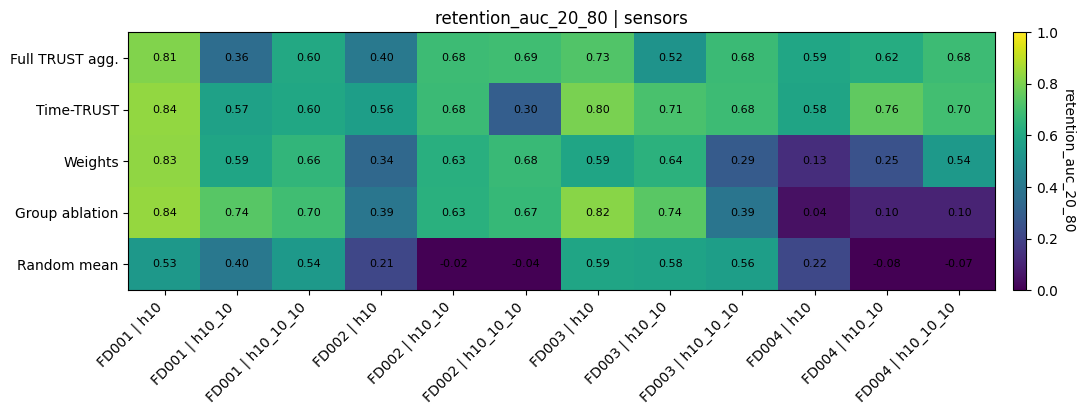

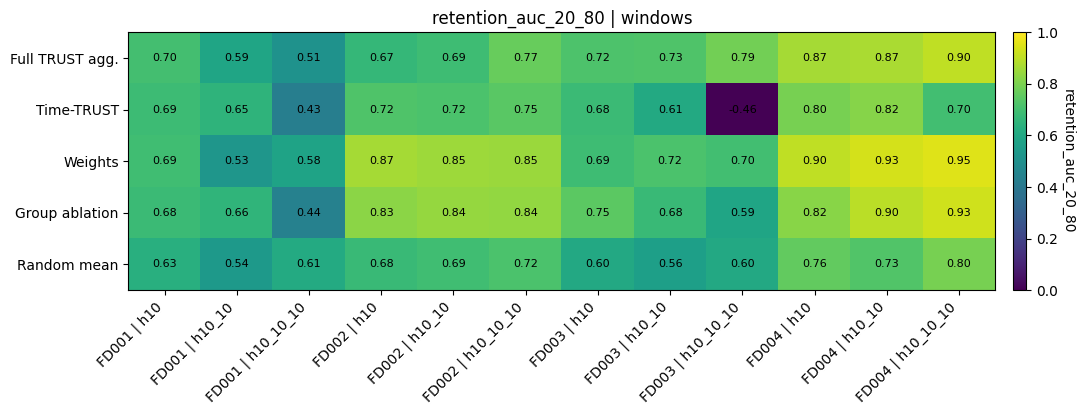

In [11]:
def _config_label(df):
    return df["dataset"].astype(str) + " | " + df["hidden_tag"].astype(str)

def plot_method_config_heatmap(data, metric="retention_auc_20_80", group_mode="sensors", *, cmap="viridis", vmin=None, vmax=None):
    sub = data[data["group_mode"].astype(str).eq(group_mode)].copy()
    if sub.empty:
        print("No data for", group_mode)
        return None

    sub["config"] = _config_label(sub)
    p = sub.pivot_table(index="method_label", columns="config", values=metric, aggfunc="mean", observed=True)

    # Orden de filas y columnas
    row_order = ["Full TRUST agg.", "Time-TRUST", "Weights", "Group ablation", "Random mean"]
    p = p.reindex([r for r in row_order if r in p.index])

    cols = []
    for ds in DATASET_ORDER:
        for h in HIDDEN_ORDER:
            c = f"{ds} | {h}"
            if c in p.columns:
                cols.append(c)
    p = p[cols]

    arr = p.to_numpy(dtype=float)
    fig_w = max(8, 0.75 * p.shape[1] + 2)
    fig_h = max(3.2, 0.55 * p.shape[0] + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(arr, aspect="auto", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(p.shape[1]))
    ax.set_xticklabels(p.columns.tolist(), rotation=45, ha="right")
    ax.set_yticks(np.arange(p.shape[0]))
    ax.set_yticklabels(p.index.tolist())
    ax.set_title(f"{metric} | {group_mode}")

    for i in range(p.shape[0]):
        for j in range(p.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
            else:
                ax.text(j, i, "NA", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.set_ylabel(metric, rotation=270, labelpad=12)
    fig.tight_layout()
    plt.show()
    return fig

_ = plot_method_config_heatmap(auc_compact, metric="retention_auc_20_80", group_mode="sensors", vmin=0, vmax=1)
_ = plot_method_config_heatmap(auc_compact, metric="retention_auc_20_80", group_mode="windows", vmin=0, vmax=1)


In [12]:
# Robust summary for retention masking results

METRIC = "retention_auc_20_80"

def iqr(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.quantile(0.75) - x.quantile(0.25)

# 1) Collapse random trials to per-configuration random mean.
id_cols = ["dataset", "window_tag", "hidden_tag", "group_mode"]

auc_det = auc[auc["method"].ne("random_permutation")].copy()

auc_rand = (
    auc[auc["method"].eq("random_permutation")]
    .groupby(id_cols, as_index=False)
    .agg(
        method=("method", lambda _: "random_mean"),
        retention_auc=("retention_auc", "mean"),
        retention_auc_20_80=("retention_auc_20_80", "mean"),
        retention_at_20=("retention_at_20", "mean"),
        retention_at_80=("retention_at_80", "mean"),
    )
)

auc_cfg = pd.concat([auc_det, auc_rand], ignore_index=True)

method_label = {
    "fulltrust_agg_selection": "Full TRUST agg.",
    "timetrust_selection": "Time-TRUST",
    "weights": "Weights",
    "group_ablation": "Group ablation",
    "random_mean": "Random mean",
}

auc_cfg["method_label"] = auc_cfg["method"].map(method_label).fillna(auc_cfg["method"])

# 2) Add paired delta vs random mean.
rand_ref = (
    auc_cfg[auc_cfg["method"].eq("random_mean")]
    [id_cols + [METRIC]]
    .rename(columns={METRIC: f"{METRIC}_random"})
)

auc_delta = auc_cfg.merge(rand_ref, on=id_cols, how="left")
auc_delta[f"delta_vs_random_{METRIC}"] = (
    auc_delta[METRIC] - auc_delta[f"{METRIC}_random"]
)
auc_delta[f"win_vs_random_{METRIC}"] = (
    auc_delta[f"delta_vs_random_{METRIC}"] > 0
).astype(float)

# 3) Robust summary.
robust_summary = (
    auc_delta
    .groupby(["group_mode", "method_label"], as_index=False)
    .agg(
        n=(METRIC, "count"),
        median_auc=(METRIC, "median"),
        iqr_auc=(METRIC, iqr),
        mean_auc=(METRIC, "mean"),
        std_auc=(METRIC, "std"),
        median_delta_vs_random=(f"delta_vs_random_{METRIC}", "median"),
        iqr_delta_vs_random=(f"delta_vs_random_{METRIC}", iqr),
        win_rate_vs_random=(f"win_vs_random_{METRIC}", "mean"),
    )
)

# 4) Nice ordering.
method_order = [
    "Time-TRUST",
    "Full TRUST agg.",
    "Group ablation",
    "Weights",
    "Random mean",
]
mode_order = pd.CategoricalDtype(["sensors", "windows"], ordered=True)
method_order_cat = pd.CategoricalDtype(method_order, ordered=True)

robust_summary["group_mode"] = robust_summary["group_mode"].astype(mode_order)
robust_summary["method_label"] = robust_summary["method_label"].astype(method_order_cat)

robust_summary = robust_summary.sort_values(["group_mode", "median_auc"], ascending=[True, False])

robust_summary_rounded = robust_summary.copy()
num_cols = robust_summary_rounded.select_dtypes(include="number").columns
robust_summary_rounded[num_cols] = robust_summary_rounded[num_cols].round(3)

display(robust_summary_rounded)

/tmp/ipykernel_101210/3640335242.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  auc[auc["method"].eq("random_permutation")]
/tmp/ipykernel_101210/3640335242.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  auc_delta


,group_mode,method_label,n,median_auc,iqr_auc,mean_auc,std_auc,median_delta_vs_random,iqr_delta_vs_random,win_rate_vs_random
3,sensors,Time-TRUST,12,0.684,0.143,0.648,0.141,0.324,0.288,1.000
1,sensors,Group ablation,12,0.652,0.426,0.514,0.297,0.178,0.152,0.833
0,sensors,Full TRUST agg.,12,0.652,0.112,0.615,0.132,0.234,0.588,0.833
4,sensors,Weights,12,0.589,0.323,0.514,0.212,0.156,0.350,0.833
2,sensors,Random mean,12,0.310,0.566,0.285,0.279,0.000,0.000,0.000
6,windows,Group ablation,12,0.786,0.166,0.745,0.142,0.118,0.087,0.833
9,windows,Weights,12,0.783,0.185,0.772,0.140,0.138,0.077,0.833
5,windows,Full TRUST agg.,12,0.723,0.123,0.733,0.116,0.090,0.088,0.750
8,windows,Time-TRUST,12,0.691,0.088,0.591,0.345,0.039,0.069,0.750
7,windows,Random mean,12,0.654,0.116,0.660,0.081,0.000,0.000,0.000


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumed available:
# auc_compact
# columns expected:
# dataset, hidden_tag, group_mode, method_label, retention_auc_20_80

DATASET_ORDER = ["FD001", "FD002", "FD003", "FD004"]
HIDDEN_ORDER = ["h10", "h10_10", "h10_10_10"]
METHOD_ORDER = ["Full TRUST agg.", "Time-TRUST", "Weights", "Group ablation", "Random mean"]

# Colors for subset names
DATASET_COLORS = {
    "FD001": "#1f77b4",
    "FD002": "#ff7f0e",
    "FD003": "#2ca02c",
    "FD004": "#d62728",
}

GROUP_MODE_TITLES = {
    "sensors": "Sensors",
    "windows": "Windows",
}


def _build_panel_pivot(
    data: pd.DataFrame,
    dataset: str,
    group_mode: str,
    metric: str,
) -> pd.DataFrame:
    sub = data[
        data["dataset"].astype(str).eq(dataset)
        & data["group_mode"].astype(str).eq(group_mode)
    ].copy()

    if sub.empty:
        return pd.DataFrame(index=METHOD_ORDER, columns=HIDDEN_ORDER, dtype=float)

    p = sub.pivot_table(
        index="method_label",
        columns="hidden_tag",
        values=metric,
        aggfunc="mean",
        observed=True,
    )

    p = p.reindex(index=METHOD_ORDER, columns=HIDDEN_ORDER)
    return p


def plot_ieee_vertical_retention_heatmaps(
    data: pd.DataFrame,
    metric: str = "retention_auc_20_80",
    *,
    cmap: str = "viridis",
    vmin: float = 0.0,
    vmax: float = 1.0,
    figsize=(7.2, 11.5),
    annotate: bool = True,
):
    fig, axes = plt.subplots(
        nrows=len(DATASET_ORDER),
        ncols=2,
        figsize=figsize,
        constrained_layout=True,
    )

    # Ensure 2D indexing always works
    axes = np.atleast_2d(axes)

    for i, dataset in enumerate(DATASET_ORDER):
        for j, group_mode in enumerate(["sensors", "windows"]):
            ax = axes[i, j]
            p = _build_panel_pivot(data, dataset, group_mode, metric)
            arr = p.to_numpy(dtype=float)

            im = ax.imshow(
                arr,
                aspect="auto",
                interpolation="nearest",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )

            # x axis = architecture
            ax.set_xticks(np.arange(len(HIDDEN_ORDER)))
            ax.set_xticklabels(HIDDEN_ORDER, rotation=45, ha="right", fontsize=8)

            # y axis = ranking methods
            ax.set_yticks(np.arange(len(METHOD_ORDER)))
            ax.set_yticklabels(METHOD_ORDER, fontsize=8)

            # Title colored by dataset/subset
            ax.set_title(
                f"{dataset} | {GROUP_MODE_TITLES[group_mode]}",
                fontsize=11,
                color=DATASET_COLORS.get(dataset, "black"),
                fontweight="bold",
                pad=8,
            )

            # Annotate cells
            if annotate:
                for r in range(arr.shape[0]):
                    for c in range(arr.shape[1]):
                        val = arr[r, c]
                        txt = "NA" if not np.isfinite(val) else f"{val:.2f}"
                        ax.text(
                            c,
                            r,
                            txt,
                            ha="center",
                            va="center",
                            fontsize=8,
                            color="black",
                        )

            # Individual colorbar per subplot
            cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
            cbar.ax.set_ylabel("Retention AUC 20–80", rotation=270, labelpad=10, fontsize=8)
            cbar.ax.tick_params(labelsize=8)

            # Optional subtle grid between cells
            ax.set_xticks(np.arange(-0.5, len(HIDDEN_ORDER), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(METHOD_ORDER), 1), minor=True)
            ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
            ax.tick_params(which="minor", bottom=False, left=False)

    fig.suptitle(
        "Retention AUC 20–80 by dataset, architecture, and grouping mode",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )

    plt.show()
    return fig

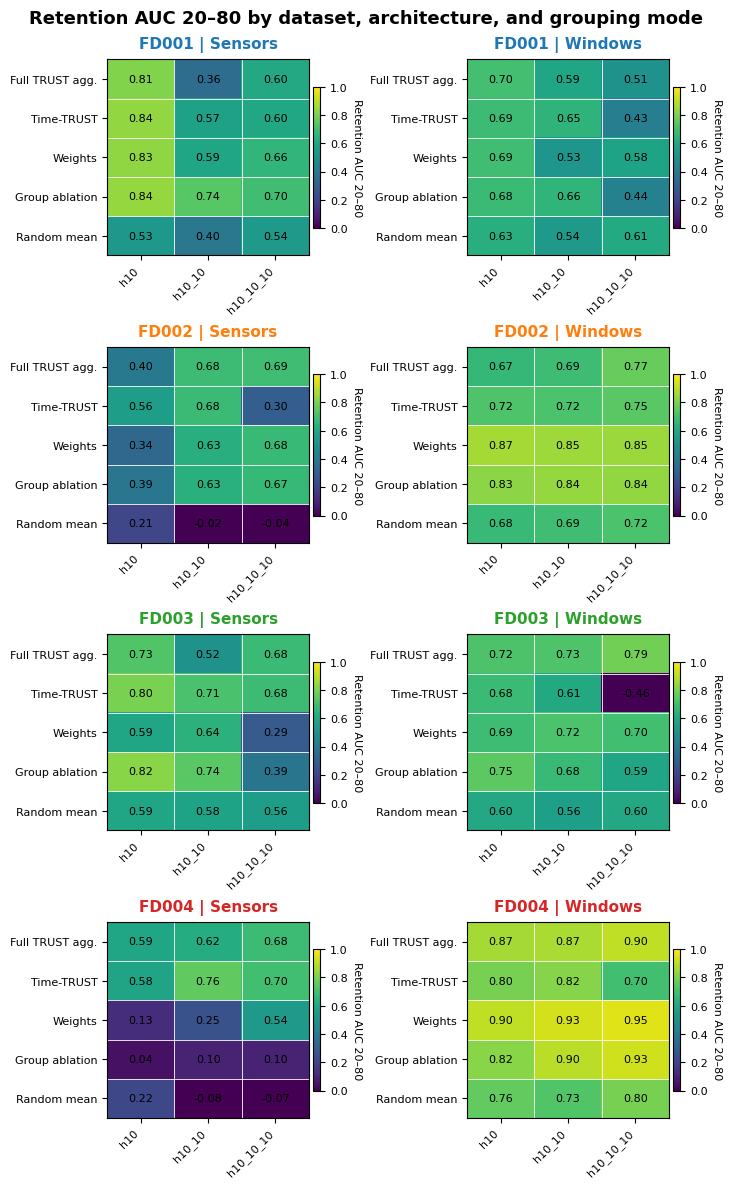

In [26]:
_ = plot_ieee_vertical_retention_heatmaps(
    auc_compact,
    metric="retention_auc_20_80",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    figsize=(7.2, 11.5),
)

In [27]:
cfg_curve = curves[
    (curves["dataset"] == "FD003")
    & (curves["window_tag"] == "W30_step1")
    & (curves["hidden_tag"] == "h10_10_10")
    & (curves["group_mode"] == "windows")
    & (curves["method"] == "timetrust_selection")
    & (curves["random_trial"] == -1)
].sort_values("k")

display(cfg_curve[[
    "k",
    "fraction_kept",
    "mae",
    "mae_empty",
    "mae_full",
    "retention",
]])

,k,fraction_kept,mae,mae_empty,mae_full,retention
22333,0,0.000000,113.444702,113.444702,28.130693,0.000000
22334,1,0.033333,110.860748,113.444702,28.130693,0.030288
22335,2,0.066667,106.742882,113.444702,28.130693,0.078555
22336,3,0.100000,110.749077,113.444702,28.130693,0.031597
22337,4,0.133333,108.702248,113.444702,28.130693,0.055588
22338,5,0.166667,114.345871,113.444702,28.130693,-0.010563
22339,6,0.200000,120.871559,113.444702,28.130693,-0.087053
22340,7,0.233333,128.219833,113.444702,28.130693,-0.173185
22341,8,0.266667,130.807404,113.444702,28.130693,-0.203515
22342,9,0.300000,129.253601,113.444702,28.130693,-0.185302


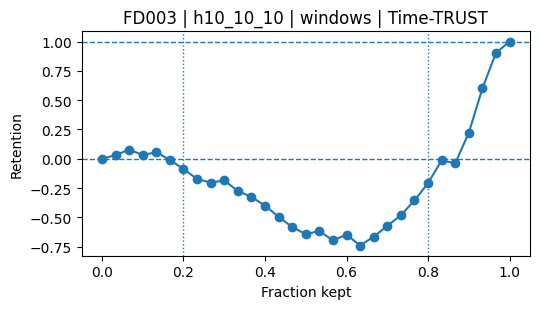

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 3.2))
plt.plot(cfg_curve["fraction_kept"], cfg_curve["retention"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.axvline(0.2, linestyle=":", linewidth=1)
plt.axvline(0.8, linestyle=":", linewidth=1)
plt.title("FD003 | h10_10_10 | windows | Time-TRUST")
plt.xlabel("Fraction kept")
plt.ylabel("Retention")
plt.tight_layout()
plt.show()

In [29]:
from pathlib import Path
import json
import pandas as pd

ranking_path = (
    Path("mlp_baselines")
    / "FD003"
    / "W30_step1"
    / "h10_10_10"
    / "rankings"
    / "ranking_windows_timetrust_selection.json"
)

with open(ranking_path, "r", encoding="utf-8") as f:
    rj = json.load(f)

rank_items = pd.DataFrame(rj["items"])
display(rank_items.head(30))

,rank,group_index_0based,group_index_1based,group_name,turned_off,off_iterpos,off_iter_idx,survived_all_iters,survival_score
0,1,13,14,w14,0,-1,-1,1,30
1,2,16,17,w17,1,29,29,0,29
2,3,0,1,w1,1,28,28,0,28
3,4,15,16,w16,1,27,27,0,27
4,5,1,2,w2,1,26,26,0,26
5,6,3,4,w4,1,25,25,0,25
6,7,2,3,w3,1,24,24,0,24
7,8,12,13,w13,1,23,23,0,23
8,9,17,18,w18,1,22,22,0,22
9,10,5,6,w6,1,21,21,0,21


In [30]:
rank_items[[
    "rank",
    "group_index_0based",
    "group_index_1based",
    "group_name",
    "survival_score",
    "off_iterpos",
    "turned_off",
    "survived_all_iters",
]]

,rank,group_index_0based,group_index_1based,group_name,survival_score,off_iterpos,turned_off,survived_all_iters
0,1,13,14,w14,30,-1,0,1
1,2,16,17,w17,29,29,1,0
2,3,0,1,w1,28,28,1,0
3,4,15,16,w16,27,27,1,0
4,5,1,2,w2,26,26,1,0
5,6,3,4,w4,25,25,1,0
6,7,2,3,w3,24,24,1,0
7,8,12,13,w13,23,23,1,0
8,9,17,18,w18,22,22,1,0
9,10,5,6,w6,21,21,1,0
